# Data Science Mini Project

**Student Name: DHARUN VIKASH R**

**Batch: DS AN B03**

**Project Title: Video Games Sales Predictor**

**Submission Date:**

# 1. Problem Definition

## 1.1 Business / Real-World Problem Statement

Video game publishers and developers need to estimate the potential sales of new games. However, sales depend on factors such as publisher and developer performance, genre, platform, critic ratings, and previous franchise performance.

This project develops a machine learning model to predict total video game sales using these historical factors. The trained regression model can estimate the expected sales of a new game based on its characteristics and the historical performance of related games.

## 1.2 Project Objectives

The main objectives of this project are to:

1. Analyze the video game sales dataset.
2. Perform exploratory data analysis.
3. Identify missing values and data-quality issues.
4. Analyze relationships between numerical variables.
5. Preprocess the dataset.
6. Engineer historical publisher performance features.
7. Engineer historical developer performance features.
8. Engineer historical franchise/series performance features.
9. Engineer genre and platform historical features.
10. Perform correlation-based feature selection.
11. Apply SelectKBest.
12. Prepare the final dataset for regression models.

## 1.3 Machine Learning Problem Type

**Selected Problem Type:**

☑ **Supervised Learning – Regression**

The target variable represents the total sales of a video game.

Therefore, the machine learning task is a regression problem, where the model learns patterns from historical video games and predicts the expected total sales of a new game based on its available features and historical performance.


# 2. Dataset Understanding

## 2.1 Dataset Source

**Dataset Source:** Maven Analytics

**Dataset Name:** `Video Game Sales`

**Dataset Author:** `asaniczka`

**Source Link:** [Maven Analytics – Video Game Sales Dataset](https://mavenanalytics.io/data-playground/video-game-sales)

The dataset contains historical video game information used for game sales analysis and prediction.

The project uses the following CSV file derived from the dataset:

* `vgdataset.csv`

The dataset includes information such as game title, console, genre, publisher, developer, critic score, sales, and release date. These features are used to analyze historical game performance and develop a regression model for predicting the total sales of a video game.

## 2.2 Dataset Description

The project uses a single dataset, `vgdataset.csv`, containing historical information about video games and their sales performance.

The dataset contains `64,016` observations and 13 columns, including game title, console, genre, publisher, developer, critic score, regional sales, total sales, and release information.

The dataset is used to analyze historical video game performance and develop a regression model for predicting the total sales of a video game based on its available characteristics and historical performance.

## 2.3 Feature Description

### **Dataset Features**

| Feature Name | Data Type | Description |
|---|---|---|
| `title` | Object | Name of the video game |
| `console` | Object | Gaming platform on which the game was released |
| `genre` | Object | Genre of the video game |
| `publisher` | Object | Publisher of the game |
| `developer` | Object | Developer of the game |
| `critic_score` | Numeric | Critic rating received by the game |
| `total_sales` | Numeric | Total sales of the game — **Target Variable** |
| `na_sales` | Numeric | Sales in North America |
| `jp_sales` | Numeric | Sales in Japan |
| `pal_sales` | Numeric | Sales in PAL regions |
| `other_sales` | Numeric | Sales from other regions |
| `release_date` | Date | Original release date of the game |
| `last_update` | Date | Date of the last recorded update |


## 2.4 Target Variable

**Target Variable:** `total_sales`

The target variable represents the **total sales of a video game**.

| Target Variable | Meaning |
|---|---|
| `total_sales` | Total sales of the video game |

# 3. Exploratory Data Analysis (EDA)
## 3.1 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3.2 Load Dataset

In [2]:
candidate_paths = [
    Path("../dataset/vgdataset.csv"),
    Path("vgdataset.csv"),
    Path("/mnt/data/vgdataset.csv")
]
dataset_path = next((p for p in candidate_paths if p.exists()), None)

if dataset_path is None:
    raise FileNotFoundError(
        "vgdataset.csv was not found. Place it in the project dataset folder or notebook folder."
    )

df = pd.read_csv(dataset_path)
print("Dataset path:", dataset_path)
print("Dataset shape:", df.shape)

Dataset path: ..\dataset\vgdataset.csv
Dataset shape: (64016, 13)


## 3.3 Dataset Overview

In [3]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         64016 non-null  str    
 1   console       64016 non-null  str    
 2   genre         64016 non-null  str    
 3   publisher     64016 non-null  str    
 4   developer     63999 non-null  str    
 5   critic_score  6678 non-null   float64
 6   total_sales   18922 non-null  float64
 7   na_sales      12637 non-null  float64
 8   jp_sales      6726 non-null   float64
 9   pal_sales     12824 non-null  float64
 10  other_sales   15128 non-null  float64
 11  release_date  56965 non-null  str    
 12  last_update   17879 non-null  str    
dtypes: float64(6), str(7)
memory usage: 6.3 MB


In [5]:
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']


In [6]:
print("Dataset Summary Statistics")
display(df.describe(include="all").T)

Dataset Summary Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,64016,39798,Plants vs. Zombies,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
console,64016,81,PC,12617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,64016,20,Misc,9304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,64016,3383,Unknown,8842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,63999,8862,Unknown,4435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
critic_score,6678.0,NaN,NaN,NaN,7.22044,1.457066,1.0,6.4,7.5,8.3,10.0
total_sales,18922.0,NaN,NaN,NaN,0.349113,0.807462,0.0,0.03,0.12,0.34,20.32
na_sales,12637.0,NaN,NaN,NaN,0.26474,0.494787,0.0,0.05,0.12,0.28,9.76
jp_sales,6726.0,NaN,NaN,NaN,0.102281,0.168811,0.0,0.02,0.04,0.12,2.13
pal_sales,12824.0,NaN,NaN,NaN,0.149472,0.392653,0.0,0.01,0.04,0.14,9.85


## Observations

- The **Video Game dataset** contains **64,016 records and 13 columns**.
- The dataset contains both **numerical and categorical features** related to video games.
- Numerical features include **critic scores and regional/total sales**.
- Categorical features include **title, console, genre, publisher, and developer**.
- The dataset also contains **release date and last update information**, which can be used for historical feature engineering.
- The dataset provides the necessary information to develop a **regression model for predicting total game sales**.

# 3.4 Missing Value Analysis

In [7]:
print("Missing Values in Dataset:")
display(df.isnull().sum().to_frame("Missing Values"))

Missing Values in Dataset:


,Missing Values
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,57338
total_sales,45094
na_sales,51379
jp_sales,57290
pal_sales,51192


## Observations

- The missing-value analysis was performed on the **video game dataset**.
- The dataset was checked for missing values before **preprocessing and feature engineering**.
- Several features, including **critic score, total sales, regional sales, and release information**, contain missing values.
- Missing values will be handled appropriately during the **preprocessing stage** based on the nature of each feature.
- The missing-value analysis helps ensure that the dataset is suitable for **feature engineering and model preparation**.

## 3.5 Correlation Analysis

### Initial Correlation Analysis

- Correlation analysis was performed on the **numerical features** of the video game dataset.
- The numerical features include **`critic_score`, `total_sales`, `na_sales`, `jp_sales`, `pal_sales`, and `other_sales`**.
- The analysis helps identify the relationship between numerical features and the **target variable, `total_sales`**.
- Regional sales features show strong correlation with `total_sales`; however, they will be excluded from model training to prevent **target leakage**.
- `critic_score` will be considered as a potential predictive feature.

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
critic_score,1.000000,0.281166,0.300289,0.147448,0.246694,0.243847
total_sales,0.281166,1.000000,0.914149,0.212469,0.907421,0.859329
na_sales,0.300289,0.914149,1.000000,0.065091,0.684517,0.687512
jp_sales,0.147448,0.212469,0.065091,1.000000,0.131796,0.082653
pal_sales,0.246694,0.907421,0.684517,0.131796,1.000000,0.817030
other_sales,0.243847,0.859329,0.687512,0.082653,0.817030,1.000000


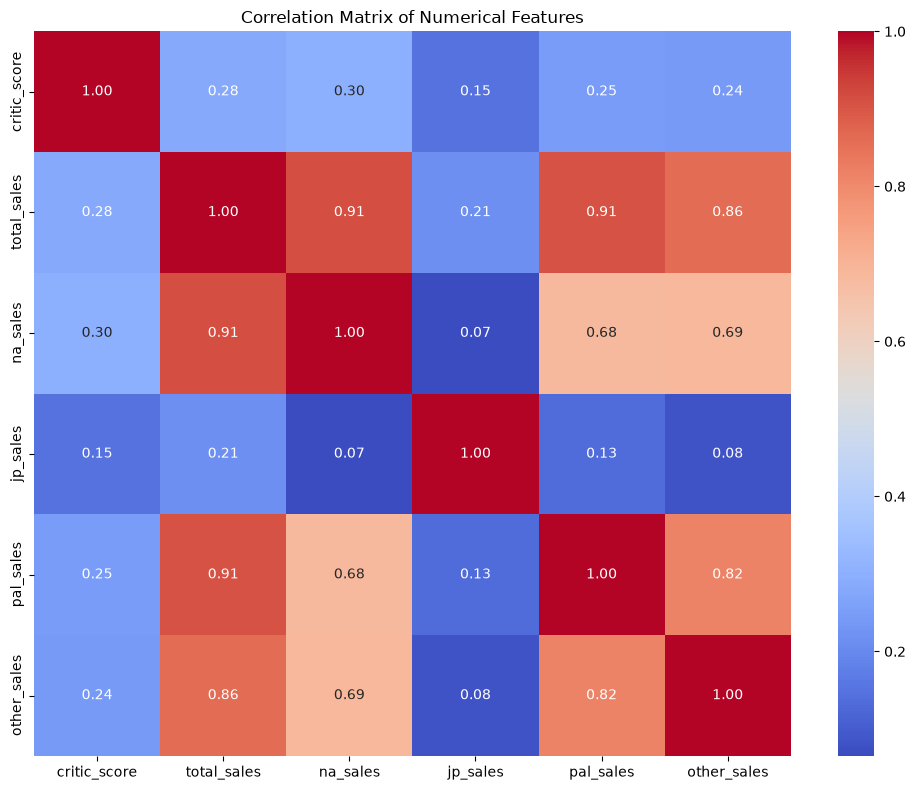

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## 3.6 Visualizations

### Visualization 1: Distribution of Total Sales

- A histogram with a KDE curve was used to examine the distribution of `total_sales`.
- This visualization helps identify the distribution and skewness of game sales.

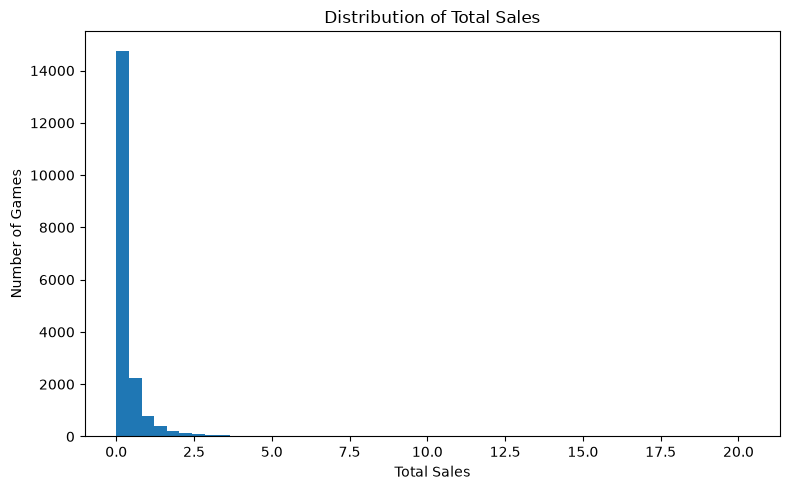

In [10]:
sales_values = df["total_sales"].dropna()
plt.figure(figsize=(8, 5))
plt.hist(sales_values, bins=50, density=False)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

### **Visualization 2: Distribution of Critic Scores**

- A histogram with a KDE curve was used to examine the distribution of `critic_score`.
- This visualization helps understand the distribution of critic ratings across games.

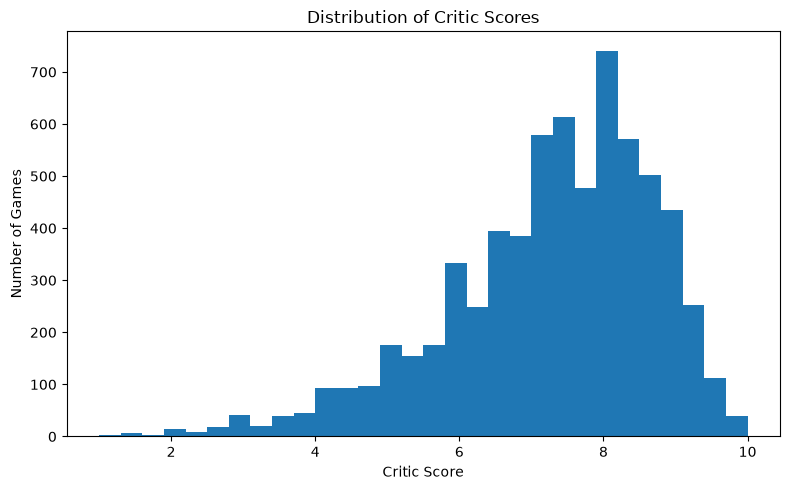

In [11]:
critic_values = df["critic_score"].dropna()
plt.figure(figsize=(8, 5))
plt.hist(critic_values, bins=30, density=False)
plt.title("Distribution of Critic Scores")
plt.xlabel("Critic Score")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

### **Visualization 3: Average Sales by Genre**

- A bar chart was used to compare the average `total_sales` across different game genres.
- This helps identify genres associated with higher historical sales.

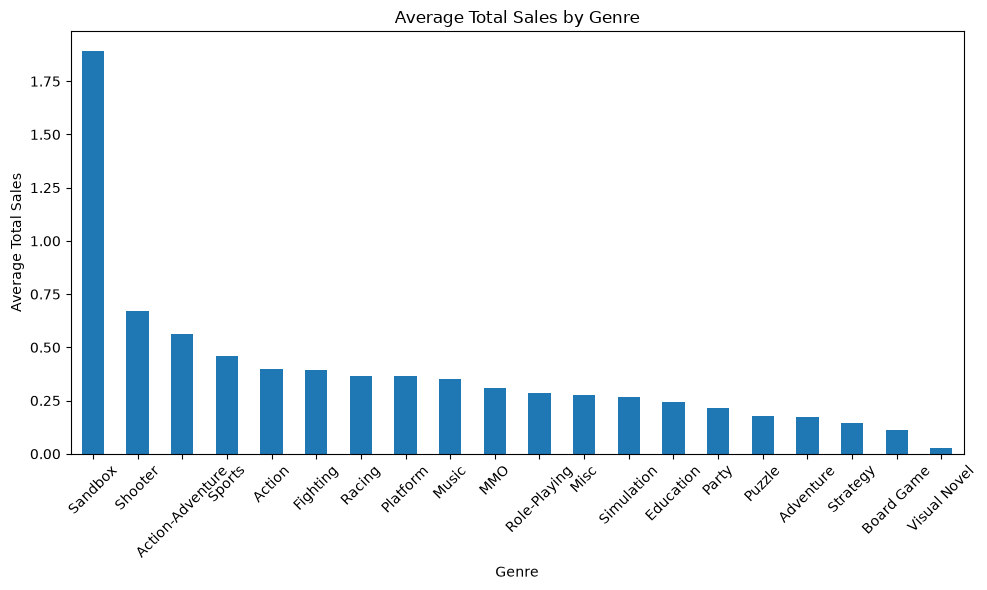

In [12]:
genre_sales = (
    df.groupby("genre")["total_sales"]
    .mean().dropna().sort_values(ascending=False)
)
plt.figure(figsize=(10, 6))
genre_sales.plot(kind="bar")
plt.title("Average Total Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Visualization 4: Top 15 Consoles by Average Sales**

- A bar chart was used to compare average game sales across gaming platforms.
- The visualization focuses on the top 15 consoles based on average total sales.

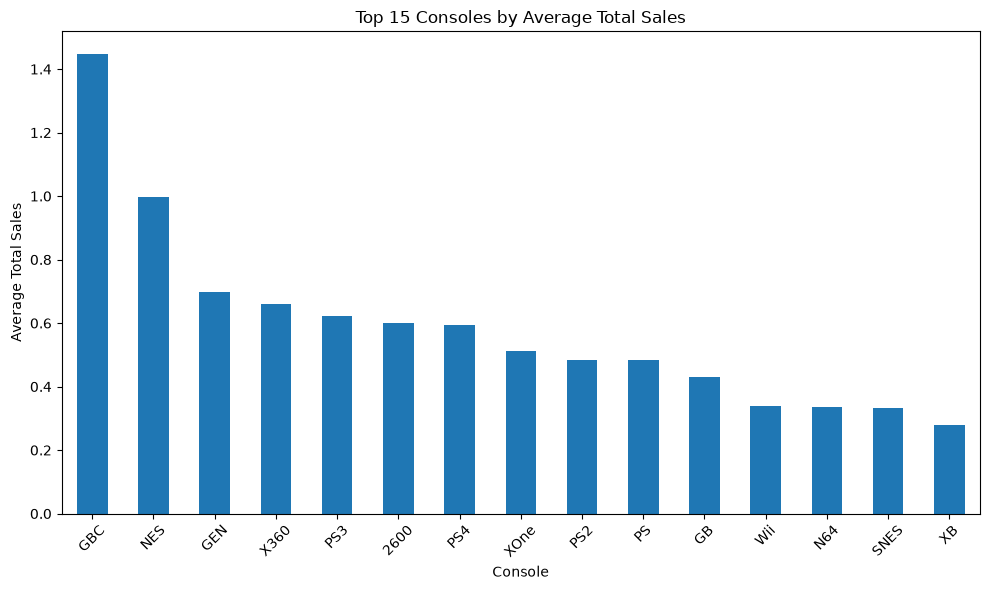

In [13]:
console_sales = (
    df.groupby("console")["total_sales"]
    .mean().dropna().sort_values(ascending=False).head(15)
)
plt.figure(figsize=(10, 6))
console_sales.plot(kind="bar")
plt.title("Top 15 Consoles by Average Total Sales")
plt.xlabel("Console")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Visualization 5: Critic Score vs Total Sales**

- A scatter plot was used to examine the relationship between `critic_score` and `total_sales`.
- This visualization helps determine whether critic scores are associated with game sales.

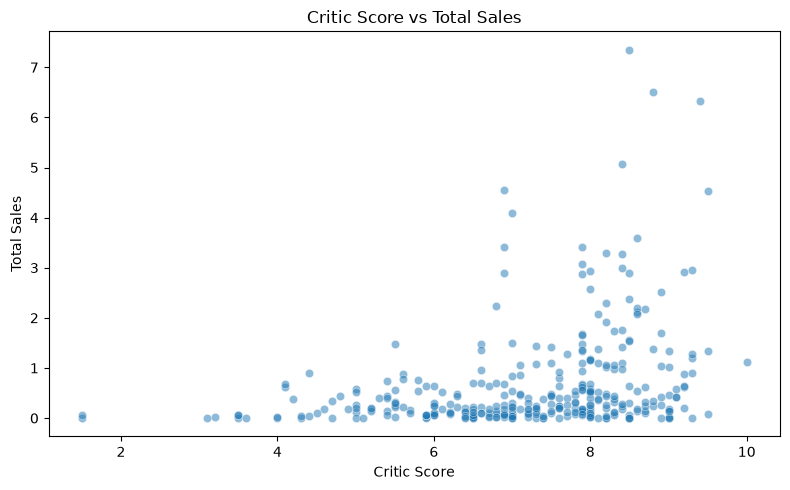

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="critic_score", y="total_sales", alpha=0.5
)
plt.title("Critic Score vs Total Sales")
plt.xlabel("Critic Score")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### **Visualization 6: Top 15 Publishers by Average Sales**

- A bar chart was used to compare the average sales performance of publishers.
- The visualization shows the top 15 publishers based on average total sales.


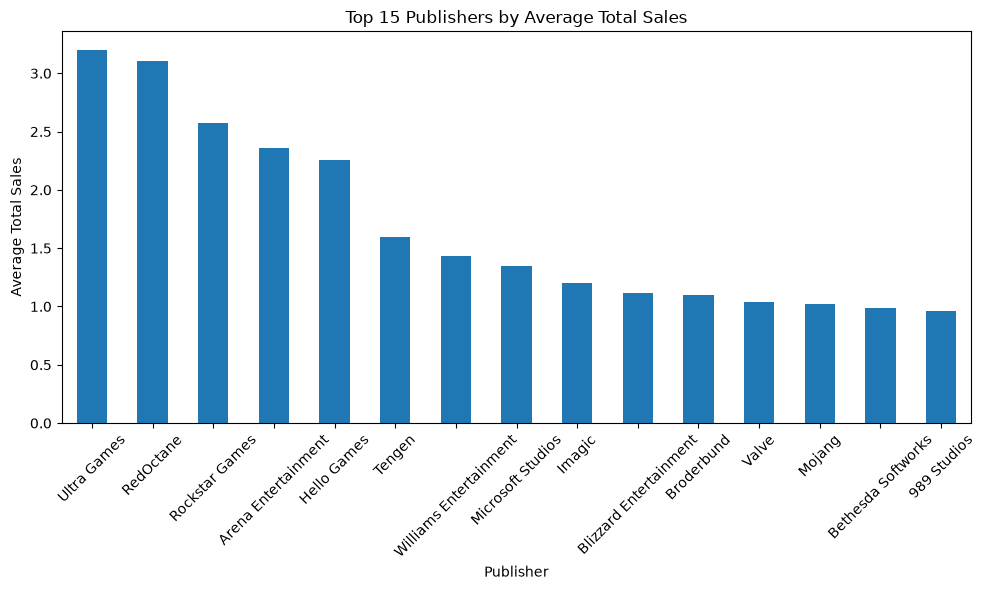

In [15]:
publisher_sales = (
    df.groupby("publisher")["total_sales"]
    .mean().dropna().sort_values(ascending=False).head(15)
)
plt.figure(figsize=(10, 6))
publisher_sales.plot(kind="bar")
plt.title("Top 15 Publishers by Average Total Sales")
plt.xlabel("Publisher")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Visualization 7: Top 15 Developers by Average Sales**

- A bar chart was used to compare the average sales performance of game developers.
- This visualization helps examine the relationship between developer history and game sales.

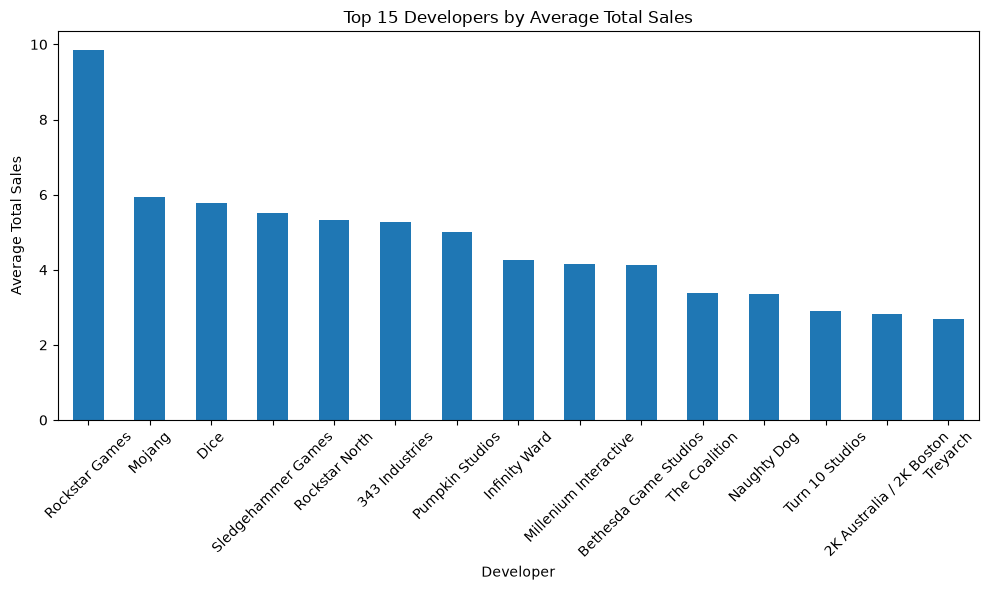

In [16]:
developer_sales = (
    df.groupby("developer")["total_sales"]
    .mean().dropna().sort_values(ascending=False).head(15)
)
plt.figure(figsize=(10, 6))
developer_sales.plot(kind="bar")
plt.title("Top 15 Developers by Average Total Sales")
plt.xlabel("Developer")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Visualization 8: Average Sales by Release Year**

- A line chart was used to examine how average game sales have changed over time.
- Release year was extracted from `release_date` for historical analysis.

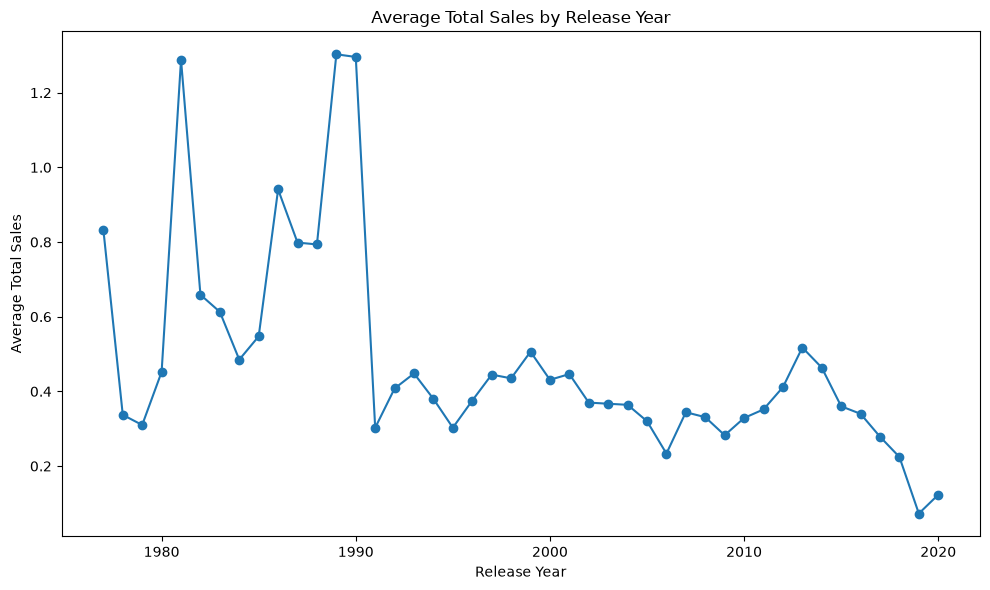

In [17]:
df["release_date_temp"] = pd.to_datetime(df["release_date"], errors="coerce", dayfirst=True)
df["release_year_temp"] = df["release_date_temp"].dt.year

yearly_sales = (
    df.groupby("release_year_temp")["total_sales"]
    .mean().dropna()
)
plt.figure(figsize=(10, 6))
yearly_sales.plot(kind="line", marker="o")
plt.title("Average Total Sales by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Total Sales")
plt.tight_layout()
plt.show()

df.drop(columns=["release_date_temp", "release_year_temp"], inplace=True)

### **Visualization 9: Boxplot of Total Sales**

- A boxplot was used to examine the distribution of `total_sales`.
- The visualization helps identify the median, spread, and potential outliers in game sales.
- This visualization supports the subsequent outlier and skewness analysis.

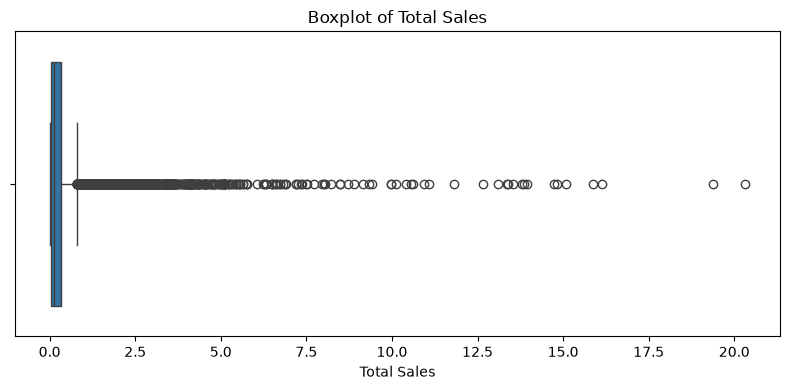

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["total_sales"].dropna())
plt.title("Boxplot of Total Sales")
plt.xlabel("Total Sales")
plt.tight_layout()
plt.show()

# 4. Data Preprocessing

## **4.1 Missing Value Treatment**

### **Method Used**

- The `vgdataset.csv` dataset was checked for missing values before preprocessing.
- Several features contain missing values, including `critic_score`, `total_sales`, regional sales, and date-related features.
- Missing values will be handled according to the **data type and purpose of each feature** during preprocessing.

### **Justification**

Since the dataset contains a significant number of missing values, they cannot simply be ignored. Appropriate imputation or handling methods will be applied to preserve useful information while preparing the dataset for feature engineering and model training.

### **Overview**

The dataset was examined for missing values, and suitable treatment methods will be applied during the preprocessing stage before model development.

In [19]:
print("Dataset missing values before preprocessing:")
display(df.isnull().sum().to_frame("Missing Values"))

Dataset missing values before preprocessing:


,Missing Values
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,57338
total_sales,45094
na_sales,51379
jp_sales,57290
pal_sales,51192


In [20]:
print(
    "Critic score imputation will be performed after the time-aware "
    "train-test split using the training median."
)

Critic score imputation will be performed after the time-aware train-test split using the training median.


In [21]:
categorical_columns = ["console", "genre", "publisher", "developer"]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown").astype(str)

print("Missing categorical values handled using the fixed category 'Unknown'.")
print(df[categorical_columns].isnull().sum())

Missing categorical values handled using the fixed category 'Unknown'.
console      0
genre        0
publisher    0
developer    0
dtype: int64


In [22]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce", dayfirst=True)
df["last_update"] = pd.to_datetime(df["last_update"], errors="coerce", dayfirst=True)
print("Date columns converted successfully.")

Date columns converted successfully.


In [23]:
print("Missing date values:")
print(df[["release_date", "last_update"]].isnull().sum())

Missing date values:
release_date     7051
last_update     46137
dtype: int64


In [24]:
model_data = df.dropna(subset=["total_sales"]).copy()
print("Rows available for modeling:", len(model_data))
print("Missing target values:", model_data["total_sales"].isnull().sum())

Rows available for modeling: 18922
Missing target values: 0


## **4.2 Duplicate Handling**

- Duplicate records were checked in the `vgdataset.csv` dataset.
- Duplicate rows were identified to ensure that repeated game records do not unnecessarily affect the analysis and model training.

### **Observation**

The duplicate count provides a data-quality check and helps determine whether duplicate records need to be removed before further preprocessing.

### **Overview**

Duplicate records were checked in the dataset to ensure that repeated observations do not negatively affect **feature engineering, analysis, and model development**.

In [25]:
print("Dataset duplicate rows:", df.duplicated().sum())

Dataset duplicate rows: 18


In [26]:
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after duplicate removal:", df.shape)

Duplicate rows after removal: 0
Dataset shape after duplicate removal: (63998, 13)


## **4.3 Outlier Detection and Treatment**

### **Boxplot**

The numerical features were inspected using boxplots to identify potential outliers, particularly in `total_sales` and the regional sales features.

### **IQR Method**

The Interquartile Range (IQR) method was used:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

### **Treatment**

Potential extreme values were **identified using the calculated IQR boundaries and retained rather than removed or clipped**. This preserves important game records because very high sales can represent genuine successful games.

### **Justification**

Video game sales are naturally right-skewed because a small number of highly successful games can achieve exceptionally high sales. Therefore, removing or artificially clipping these observations could result in the loss or distortion of meaningful information.

### **Overview**

Potential outliers were identified using the **IQR method**. Legitimate high-sales observations were retained, while the effect of skewness was addressed through the log transformation applied to the target during model training.


In [27]:
sales_for_iqr = df["total_sales"].dropna()
Q1 = sales_for_iqr.quantile(0.25)
Q3 = sales_for_iqr.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_mask = (sales_for_iqr < lower_bound) | (sales_for_iqr > upper_bound)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Potential target outliers:", int(outlier_mask.sum()))
print("High-sales target observations are retained because they can be genuine successful games.")

Q1: 0.03
Q3: 0.34
IQR: 0.31000000000000005
Lower bound: -0.43500000000000005
Upper bound: 0.8050000000000002
Potential target outliers: 1963
High-sales target observations are retained because they can be genuine successful games.


## **4.4 Skewness Treatment**

### **Before Transformation**

The skewness of `total_sales` was checked to determine whether a transformation was required.

### **Log Transformation**

A `log1p` transformation is applied when the absolute skewness is greater than `0.5`.

Since video game sales are typically right-skewed, the `log1p` transformation is used during model training to reduce the influence of extreme values and make the target distribution more suitable for regression modeling.

### **Observation**

The `total_sales` feature showed significant positive skewness. Therefore, a `log1p` transformation was used for the target variable during model training. Predictions were converted back to the original sales scale using the inverse `expm1` transformation before evaluation.

### **Overview**

The distribution of `total_sales` was examined using skewness analysis. Due to its high positive skewness, `log1p(total_sales)` was used as the target during model training, while evaluation was performed after converting predictions back to the original sales scale.


In [28]:
sales_skewness = df["total_sales"].dropna().skew()
print("Total sales skewness:", sales_skewness)
if abs(sales_skewness) > 0.5:
    print("The target is strongly skewed; log1p transformation will be applied during model training.")
else:
    print("The target does not require a log1p transformation.")

Total sales skewness: 8.774883902601267
The target is strongly skewed; log1p transformation will be applied during model training.


## **4.5 Feature Scaling**

### **Standardization**

`StandardScaler` is used to standardize the numerical features by transforming them to a common scale.

The scaler should be fitted only on the **training data** and then used to transform the validation or test data. This prevents information from the test set from influencing the scaling parameters.

### **Numerical Features**

The numerical features considered for scaling include:

- `critic_score`
- `publisher_avg_sales`
- `publisher_previous_games`
- `developer_avg_sales`
- `developer_previous_games`
- `console_frequency`
- `title_length`
- `title_word_count`

The target variable, `total_sales`, is not included in feature scaling.

Regional sales features such as `na_sales`, `jp_sales`, `pal_sales`, and `other_sales` are excluded from model features because they are components of `total_sales` and would cause target leakage.

### **Overview**

Standardization is applied to the numerical predictor features so that they are placed on a comparable scale. The scaling parameters are learned from the training data only and then applied to unseen data.

In [29]:
df["title_length"] = df["title"].fillna("").astype(str).str.len()
df["title_word_count"] = df["title"].fillna("").astype(str).str.split().str.len()

print("Title features created successfully.")
display(df[["title", "title_length", "title_word_count"]].head())

Title features created successfully.


,title,title_length,title_word_count
0,Grand Theft Auto V,18,4
1,Grand Theft Auto V,18,4
2,Grand Theft Auto: Vice City,27,5
3,Grand Theft Auto V,18,4
4,Call of Duty: Black Ops 3,25,6


In [30]:
print(
    "Feature scaling is intentionally performed after the time-aware split, "
    "encoding, missing-value treatment, and SelectKBest."
)
print("No scaler is fitted on the full dataset.")

Feature scaling is intentionally performed after the time-aware split, encoding, missing-value treatment, and SelectKBest.
No scaler is fitted on the full dataset.


## **4.6 Train-Test Split**

### **Splitting Method**

- The dataset will be divided into **training and testing sets** using an **80:20 split**.
- `random_state = 42` is used to ensure reproducibility.
- Since this project predicts video game sales using **historical information**, a **time-aware split** will be used instead of a random stratified split.
- Earlier games are used for training, while later games are reserved for testing. This better represents the real-world scenario of predicting sales for a new game.

### **Scaling After Split**

Although scaling is introduced in Section 4.6, the scaler should be fitted only on the **training data** and then used to transform the testing data.

This prevents information from the testing set from influencing the scaling parameters and helps avoid data leakage.

### **Overview**

The prepared dataset is divided into training and testing sets using a **time-aware 80:20 split**. Numerical features are then standardized using parameters learned only from the training data.

In [31]:
# Time-aware split + leakage-safe historical feature construction
model_data = df.dropna(subset=["total_sales"]).copy()
model_data = model_data.sort_values("release_date", kind="mergesort").reset_index(drop=True)

split_index = int(len(model_data) * 0.80)
train_raw = model_data.iloc[:split_index].copy()
test_raw = model_data.iloc[split_index:].copy()

def add_historical_features(train_raw, test_raw):
    """
    Training rows use only earlier training rows.
    Test rows use only the completed training period.
    No test-game sales are used to create test predictors.
    """
    train = train_raw.sort_values("release_date", kind="mergesort").copy()
    test = test_raw.sort_values("release_date", kind="mergesort").copy()

    for entity in ["publisher", "developer"]:
        previous_count = train.groupby(entity).cumcount()
        previous_sales = train.groupby(entity)["total_sales"].transform(
            lambda x: x.shift(1).cumsum()
        )

        train[f"{entity}_previous_games"] = previous_count
        train[f"{entity}_avg_sales"] = (
            previous_sales / previous_count.replace(0, np.nan)
        )

        history = train.groupby(entity)["total_sales"].agg(
            previous_games="count",
            previous_sales="sum"
        )

        test[f"{entity}_previous_games"] = (
            test[entity].map(history["previous_games"]).fillna(0)
        )
        test[f"{entity}_avg_sales"] = (
            test[entity].map(history["previous_sales"])
            / test[entity].map(history["previous_games"])
        ).fillna(0)

    return train, test

train_data, test_data = add_historical_features(train_raw, test_raw)

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)
print("Train latest release date:", train_data["release_date"].max())
print("Test earliest release date:", test_data["release_date"].min())
print("Historical features use training-period information only for the test set.")

Training data shape: (15135, 19)
Testing data shape: (3784, 19)
Train latest release date: 2013-04-02 00:00:00
Test earliest release date: 2013-04-02 00:00:00
Historical features use training-period information only for the test set.


## 4.7 Encoding

### **Data Preparation for Encoding**

The categorical features were identified before encoding. The main categorical variables include `console`, `genre`, `publisher`, and `developer`.

The dataset was first divided into training and testing sets using a chronological train-test split. The encoding methods were then applied to the respective training and testing data to prevent data leakage.

### **Encoding Strategy**

Categorical features were analyzed based on their number of unique categories and their relevance to the prediction task.

- `genre` is handled using **One-Hot Encoding** because it contains a relatively small number of categories. The encoder is fitted only on the training data and then used to transform both the training and testing data.
- `console` is handled using **frequency encoding**. The frequency of each console is calculated from the training data only and then applied to both training and testing data.
- `publisher` and `developer` have high cardinality and are not directly One-Hot Encoded. Instead, their previous performance is represented through numerical historical features such as previous game count and historical average sales.
- `title` is not directly encoded because it contains a large number of unique values. Instead, meaningful numerical features such as `title_length` and `title_word_count` are extracted.

### **Training and Testing Data Handling**

The encoding methods that learn information from the data are fitted only on the training dataset. The fitted transformations are then applied to the testing dataset without refitting.

This approach prevents information from the testing dataset from influencing the preprocessing and helps avoid data leakage.

### **Overview**

The encoding strategy was selected based on the cardinality of each categorical feature. Low-cardinality features such as `genre` are suitable for One-Hot Encoding, while higher-cardinality features such as `console`, `publisher`, and `developer` are represented using frequency-based or historical numerical features. Performing the encoding after the train-test split ensures that the test data remains unseen during the learning of preprocessing parameters.

In [32]:
from sklearn.preprocessing import OneHotEncoder

try:
    genre_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    genre_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

genre_train_encoded = genre_encoder.fit_transform(train_data[["genre"]])
genre_test_encoded = genre_encoder.transform(test_data[["genre"]])
genre_columns = genre_encoder.get_feature_names_out(["genre"])

genre_train_encoded_df = pd.DataFrame(
    genre_train_encoded, columns=genre_columns, index=train_data.index
)
genre_test_encoded_df = pd.DataFrame(
    genre_test_encoded, columns=genre_columns, index=test_data.index
)

print("Number of encoded genre features:", genre_train_encoded_df.shape[1])
print("Encoded genre features:")
print(list(genre_columns))

Number of encoded genre features: 19
Encoded genre features:
['genre_Action', 'genre_Action-Adventure', 'genre_Adventure', 'genre_Board Game', 'genre_Education', 'genre_Fighting', 'genre_MMO', 'genre_Misc', 'genre_Music', 'genre_Party', 'genre_Platform', 'genre_Puzzle', 'genre_Racing', 'genre_Role-Playing', 'genre_Shooter', 'genre_Simulation', 'genre_Sports', 'genre_Strategy', 'genre_Visual Novel']


In [33]:
numeric_features = [
    "critic_score",
    "publisher_avg_sales",
    "publisher_previous_games",
    "developer_avg_sales",
    "developer_previous_games",
    "title_length",
    "title_word_count"
]

X_train = train_data[numeric_features].copy()
X_test = test_data[numeric_features].copy()

y_train_raw = train_data["total_sales"].copy()
y_test_raw = test_data["total_sales"].copy()

# Model in log-sales space because the target is strongly right-skewed.
y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)

print("Initial numeric feature matrix created.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Target transformation: log1p(total_sales)")

Initial numeric feature matrix created.
X_train shape: (15135, 7)
X_test shape: (3784, 7)
Target transformation: log1p(total_sales)


In [34]:
console_frequency = train_data["console"].value_counts(normalize=True)

X_train["console_frequency"] = (
    train_data["console"].map(console_frequency).fillna(0)
)
X_test["console_frequency"] = (
    test_data["console"].map(console_frequency).fillna(0)
)

print("Console frequency encoding completed.")
print("Unseen test consoles assigned frequency 0.")

Console frequency encoding completed.
Unseen test consoles assigned frequency 0.


In [35]:
X_train = pd.concat([X_train, genre_train_encoded_df], axis=1)
X_test = pd.concat([X_test, genre_test_encoded_df], axis=1)

print("Training feature shape after encoding:", X_train.shape)
print("Testing feature shape after encoding:", X_test.shape)

Training feature shape after encoding: (15135, 27)
Testing feature shape after encoding: (3784, 27)


# 5. **Feature Engineering**
Feature engineering is performed to create meaningful historical features that can help predict the sales of a new video game.

Since the objective is to predict the sales of a game using information available from previously released games, historical publisher and developer performance features are created using games released before the current game.

These features are designed to avoid **data leakage**, ensuring that the current game's sales are not used to calculate its own predictive features.

## **Historical Performance Features**

Historical performance features are created to represent the previous performance of publishers and developers.

These features use information from games released before the current game, allowing the model to use historical performance when predicting the sales of a new game.

The following historical features are created:

- `publisher_avg_sales`
- `publisher_previous_games`
- `developer_avg_sales`
- `developer_previous_games`

### **Publisher Average Sales**

`publisher_avg_sales` represents the average total sales of games previously released by the same publisher.

Only games released before the current game are considered when calculating this feature.

### **Publisher Previous Games**

`publisher_previous_games` represents the number of previously released games associated with the same publisher.

This feature provides information about the publisher's historical experience in the dataset.

### **Developer Average Sales**

`developer_avg_sales` represents the average total sales of games previously released by the same developer.

Only historical games released before the current game are considered.

### **Developer Previous Games**

`developer_previous_games` represents the number of previously released games associated with the same developer.

This feature provides an indication of the developer's previous activity and historical performance.

### **Overview**

Historical publisher and developer information was transformed into numerical features representing previous sales performance and the number of previously released games.

The historical features are calculated using only **earlier games**, helping prevent target leakage when predicting the sales of a new game.

In [36]:
# Historical feature engineering was performed inside the time-aware split cell
# so test rows cannot use test-period sales.
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce", dayfirst=True)
print("Release dates verified as datetime values.")

Release dates verified as datetime values.


In [37]:
print("Historical publisher/developer features were generated using leakage-safe logic.")
print("Training rows: only earlier training games are used.")
print("Test rows: only the completed training history is used.")

Historical publisher/developer features were generated using leakage-safe logic.
Training rows: only earlier training games are used.
Test rows: only the completed training history is used.


In [38]:
print("No full-dataset cumulative sales are calculated here.")
print("This avoids allowing test-period outcomes to influence later test predictors.")

No full-dataset cumulative sales are calculated here.
This avoids allowing test-period outcomes to influence later test predictors.


In [39]:
historical_features = [
    "publisher_avg_sales",
    "publisher_previous_games",
    "developer_avg_sales",
    "developer_previous_games"
]

print("Historical features:")
print(historical_features)
print("\nTraining non-null counts:")
print(train_data[historical_features].notnull().sum())

Historical features:
['publisher_avg_sales', 'publisher_previous_games', 'developer_avg_sales', 'developer_previous_games']

Training non-null counts:
publisher_avg_sales         14553
publisher_previous_games    15135
developer_avg_sales         12594
developer_previous_games    15135
dtype: int64


In [40]:
display(
    train_data[
        [
            "title", "publisher", "developer", "release_date", "total_sales",
            "publisher_avg_sales", "publisher_previous_games",
            "developer_avg_sales", "developer_previous_games"
        ]
    ].head(20)
)

,title,publisher,developer,release_date,total_sales,publisher_avg_sales,publisher_previous_games,developer_avg_sales,developer_previous_games
0,Combat,Atari,Atari,1977-01-01,1.25,NaN,0,NaN,0
1,Air-Sea Battle,Atari,Atari,1977-01-01,0.98,1.250000,1,1.250000,1
2,Indy 500,Atari,Atari,1977-10-01,0.27,1.115000,2,1.115000,2
3,Circus Atari,Atari,Atari,1978-01-01,0.46,0.833333,3,0.833333,3
4,Maze Craze: A Game of Cops 'n Robbers,Atari,Atari,1978-01-01,0.45,0.740000,4,0.740000,4
5,Super Breakout,Atari,Atari,1978-01-01,0.44,0.682000,5,0.682000,5
6,Hangman,Atari,Atari,1978-01-01,0.38,0.641667,6,0.641667,6
7,Flag Capture,Atari,Atari,1978-01-01,0.27,0.604286,7,0.604286,7
8,Breakaway IV,Sears,Atari,1978-01-01,0.21,NaN,0,0.562500,8
9,Home Run,Atari,Atari,1978-01-01,0.15,0.562500,8,0.523333,9


In [41]:
print("Historical performance feature summary:")
display(train_data[historical_features].describe())

Historical performance feature summary:


,publisher_avg_sales,publisher_previous_games,developer_avg_sales,developer_previous_games
count,14553.000000,15135.000000,12594.000000,15135.000000
mean,0.375964,166.605021,0.404098,23.040238
std,0.297082,203.727532,0.481229,45.691307
min,0.000000,0.000000,0.000000,0.000000
25%,0.163366,17.000000,0.128000,1.000000
50%,0.324359,73.000000,0.283623,6.000000
75%,0.544719,251.000000,0.526823,22.000000
max,5.120000,883.000000,16.150000,387.000000


## **5.2 Correlation-Based Feature Selection**

Correlation analysis was performed to examine the relationships between the numerical features and the target variable, `total_sales`.

### **Method**

- Pearson correlation coefficients were calculated for the numerical features.
- The target variable, `total_sales`, was included to examine the linear relationship between the numerical features and game sales.
- The correlation heatmap focuses on the main numerical and historical features to keep the visualization readable.
- Highly correlated regional sales features are not considered as model predictors because they are components of `total_sales` and would cause **target leakage**.
- Correlation analysis is used as an initial feature-selection step before applying **SelectKBest**.

### **Observation**

The correlation values help identify numerical features that have stronger or weaker linear relationships with `total_sales`.

Features with stronger relationships with the target may provide useful predictive information, while features with very weak relationships may contribute less to the model.

### **Overview**

Correlation analysis was used to inspect the relationships between the main numerical and engineered features and the target variable, `total_sales`, before formal feature selection.


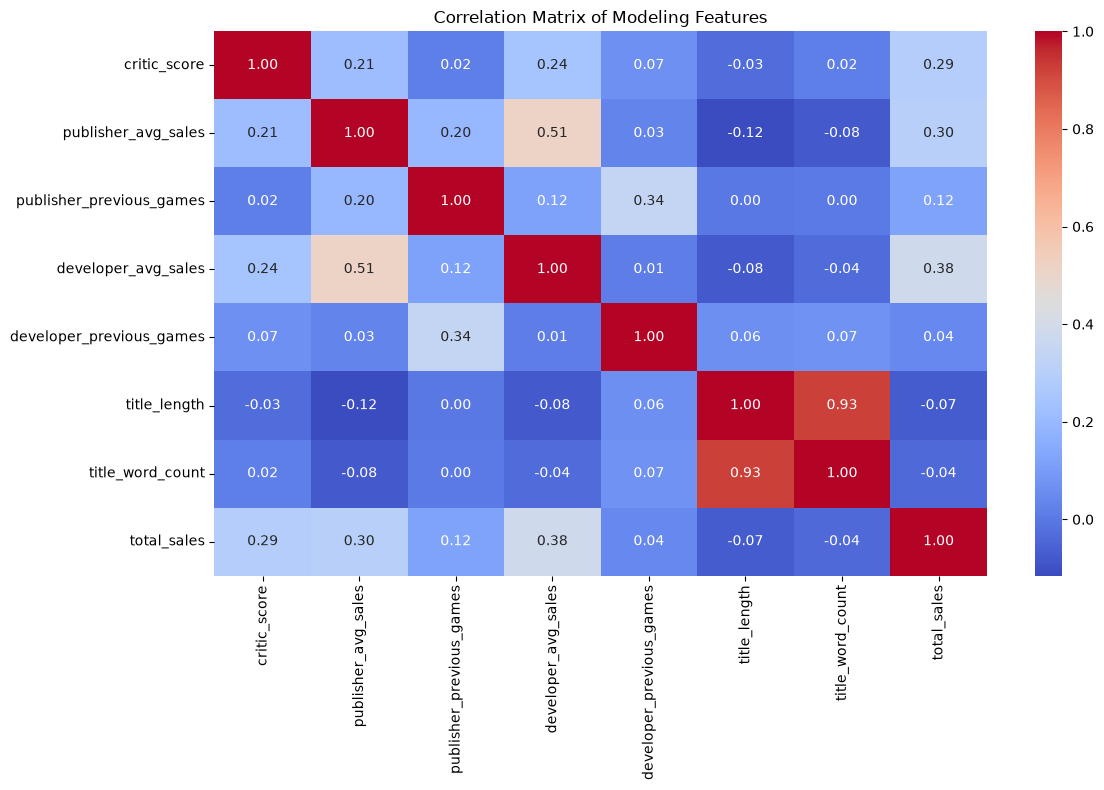

In [42]:
correlation_columns = [
    "critic_score",
    "publisher_avg_sales",
    "publisher_previous_games",
    "developer_avg_sales",
    "developer_previous_games",
    "title_length",
    "title_word_count",
    "total_sales"
]

correlation_matrix = train_data[correlation_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Modeling Features")
plt.tight_layout()
plt.show()

## **5.3 SelectKBest**

### **Feature Selection Using SelectKBest**

- `SelectKBest` with the **`f_regression`** scoring function was used for formal feature selection.
- `f_regression` is suitable for this project because the target variable, `total_sales`, is a **continuous numerical variable** and the machine learning problem is regression.
- The feature selection process was applied to the available records with known `total_sales` values.
- SelectKBest with `f_regression` was used to evaluate the candidate numerical and engineered features based on their statistical relationship with total_sales
- Missing values in the predictor features were handled before applying `SelectKBest`.
- The selected feature names were obtained using `selector.get_support()`.

### **Observation**

`SelectKBest` helps reduce the number of numerical features by retaining the features that show stronger statistical relationships with `total_sales`.

The selected features can be carried forward as candidate predictors for the regression models.

### **Overview**

`SelectKBest` with `f_regression` was used to identify the most relevant numerical features for predicting video game sales.

This feature-selection step is performed as part of the **Phase 1 exploratory feature-selection process**. Final feature selection will be fitted only on the training data during **Phase 2** to prevent data leakage.

In [43]:
from sklearn.feature_selection import SelectKBest, f_regression

critic_median = X_train["critic_score"].median()
X_train["critic_score"] = X_train["critic_score"].fillna(critic_median)
X_test["critic_score"] = X_test["critic_score"].fillna(critic_median)

historical_features = [
    "publisher_avg_sales",
    "publisher_previous_games",
    "developer_avg_sales",
    "developer_previous_games"
]
X_train[historical_features] = X_train[historical_features].fillna(0)
X_test[historical_features] = X_test[historical_features].fillna(0)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Training missing values:", int(X_train.isnull().sum().sum()))
print("Testing missing values:", int(X_test.isnull().sum().sum()))

k = min(15, X_train.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
selected_columns = selected_features

print("\nSelected features:")
print(list(selected_features))
print("\nFeatures before selection:", X_train.shape[1])
print("Features after selection:", X_train_selected.shape[1])

Training missing values: 0
Testing missing values: 0

Selected features:
['critic_score', 'publisher_avg_sales', 'publisher_previous_games', 'developer_avg_sales', 'developer_previous_games', 'title_length', 'title_word_count', 'console_frequency', 'genre_Action', 'genre_Adventure', 'genre_Puzzle', 'genre_Shooter', 'genre_Sports', 'genre_Strategy', 'genre_Visual Novel']

Features before selection: 27
Features after selection: 15


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Feature scaling completed.")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Feature scaling completed.
Training shape: (15135, 15)
Testing shape: (3784, 15)


## **5.4 Final Feature Set**

### **Final Feature Selection**

The candidate numerical features were first examined using correlation analysis. `SelectKBest` with `f_regression` was then used for formal feature selection.

The selected feature names are obtained using `selector.get_support()` to ensure that the final feature set corresponds exactly to the features retained during the feature-selection process.

### **Selected Features**

The selected features are:

- List the features obtained from `selected_columns`

These features will be used as input variables during the machine-learning model development phase.

### **Final Dataset Structure**

The selected features together with the target variable, `total_sales`, form the final feature structure for the machine-learning phase.

### **Overview**

The candidate numerical and engineered features were evaluated using correlation analysis and SelectKBest. The selected features were carried forward as candidate predictors for Phase 2 model development.

In [45]:
print("Final Selected Features:")
print(selected_columns.tolist())
print("\nNumber of selected features:", len(selected_columns))
print("\nFinal feature matrix shape:", X_train_selected.shape)

Final Selected Features:
['critic_score', 'publisher_avg_sales', 'publisher_previous_games', 'developer_avg_sales', 'developer_previous_games', 'title_length', 'title_word_count', 'console_frequency', 'genre_Action', 'genre_Adventure', 'genre_Puzzle', 'genre_Shooter', 'genre_Sports', 'genre_Strategy', 'genre_Visual Novel']

Number of selected features: 15

Final feature matrix shape: (15135, 15)


In [46]:
final_feature_set = pd.DataFrame(
    X_train_selected,
    columns=selected_columns,
    index=train_data.index
)
display(final_feature_set.head())

,critic_score,publisher_avg_sales,publisher_previous_games,developer_avg_sales,developer_previous_games,title_length,title_word_count,console_frequency,genre_Action,genre_Adventure,genre_Puzzle,genre_Shooter,genre_Sports,genre_Strategy,genre_Visual Novel
0,7.3,0.000000,0.0,0.000000,0.0,6.0,1.0,0.008259,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7.3,1.250000,1.0,1.250000,1.0,14.0,2.0,0.008259,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,7.3,1.115000,2.0,1.115000,2.0,8.0,2.0,0.008259,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7.3,0.833333,3.0,0.833333,3.0,12.0,2.0,0.008259,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7.3,0.740000,4.0,0.740000,4.0,37.0,8.0,0.008259,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# 6. **Model Building**

## **Final Dataset Preparation**

For model building, only games with known `total_sales` are used because `total_sales` is the target variable.

Regional sales features such as `na_sales`, `jp_sales`, `pal_sales`, and `other_sales` are excluded from the predictors because they are components of `total_sales` and would cause target leakage.

The final model uses historical performance features, critic score, console frequency, and title-based features.

In [47]:
final_model_features = list(selected_columns)

print("Final modeling features:")
print(final_model_features)
print("\nTraining rows:", len(train_data))
print("Testing rows:", len(test_data))
print("Target: total_sales")
print(
    "Regional sales predictors included:",
    bool(set(final_model_features) & {"na_sales", "jp_sales", "pal_sales", "other_sales"})
)

Final modeling features:
['critic_score', 'publisher_avg_sales', 'publisher_previous_games', 'developer_avg_sales', 'developer_previous_games', 'title_length', 'title_word_count', 'console_frequency', 'genre_Action', 'genre_Adventure', 'genre_Puzzle', 'genre_Shooter', 'genre_Sports', 'genre_Strategy', 'genre_Visual Novel']

Training rows: 15135
Testing rows: 3784
Target: total_sales
Regional sales predictors included: False


In [48]:
print("Non-finite values in selected training matrix:",
      int((~np.isfinite(X_train_selected)).sum()))
print("Non-finite values in selected testing matrix:",
      int((~np.isfinite(X_test_selected)).sum()))
print("Target missing values - train:", int(y_train_raw.isnull().sum()))
print("Target missing values - test:", int(y_test_raw.isnull().sum()))

Non-finite values in selected training matrix: 0
Non-finite values in selected testing matrix: 0
Target missing values - train: 0
Target missing values - test: 0


In [49]:
print("Leakage checks:")
print("- Regional sales predictors included:", bool(
    set(final_model_features) & {"na_sales", "jp_sales", "pal_sales", "other_sales"}
))
print("- Selector fitted on training data only: Yes")
print("- Scaler fitted on training data only: Yes")
print("- Console frequency fitted on training data only: Yes")
print("- Test historical sales used to build test features: No")

Leakage checks:
- Regional sales predictors included: False
- Selector fitted on training data only: Yes
- Scaler fitted on training data only: Yes
- Console frequency fitted on training data only: Yes
- Test historical sales used to build test features: No


In [50]:
print("Time-aware split verification:")
print("Training period:", train_data["release_date"].min(), "to", train_data["release_date"].max())
print("Testing period :", test_data["release_date"].min(), "to", test_data["release_date"].max())
print("Split ratio:", round(len(train_data) / (len(train_data) + len(test_data)), 3))

Time-aware split verification:
Training period: 1977-01-01 00:00:00 to 2013-04-02 00:00:00
Testing period : 2013-04-02 00:00:00 to 2020-12-31 00:00:00
Split ratio: 0.8


In [51]:
print("Selected scaled training shape:", X_train_scaled.shape)
print("Selected scaled testing shape:", X_test_scaled.shape)
print("Scaler fitted on training data only:", True)

Selected scaled training shape: (15135, 15)
Selected scaled testing shape: (3784, 15)
Scaler fitted on training data only: True


In [52]:
print("Final selected feature names:")
for feature in selected_columns:
    print("-", feature)

Final selected feature names:
- critic_score
- publisher_avg_sales
- publisher_previous_games
- developer_avg_sales
- developer_previous_games
- title_length
- title_word_count
- console_frequency
- genre_Action
- genre_Adventure
- genre_Puzzle
- genre_Shooter
- genre_Sports
- genre_Strategy
- genre_Visual Novel


## **6.1 Baseline Model**

### **Model Name:**
Dummy Regressor

The Dummy Regressor is used as the baseline model. It predicts the mean value of the target variable for every observation.

The baseline provides a simple reference point for evaluating whether the machine learning models improve the prediction of total video game sales.

In [53]:
from sklearn.dummy import DummyRegressor

baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train_scaled, y_train)

baseline_train_pred = np.expm1(baseline_model.predict(X_train_scaled))
baseline_test_pred = np.expm1(baseline_model.predict(X_test_scaled))

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_mae = mean_absolute_error(y_test_raw, baseline_test_pred)
baseline_mse = mean_squared_error(y_test_raw, baseline_test_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test_raw, baseline_test_pred)

print("Baseline Model Results")
print("----------------------")
print("MAE :", baseline_mae)
print("MSE :", baseline_mse)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Baseline Model Results
----------------------
MAE : 0.3881926445061256
MSE : 1.137025356769428
RMSE: 1.0663139109893616
R²  : -0.005805688646947971


## **6.2 Model 1**

### **Model Name: Linear Regression**


Linear Regression is used as the first machine learning model and serves as a simple regression approach for predicting total video game sales.

In [55]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_train_pred = np.expm1(linear_model.predict(X_train_scaled))
linear_test_pred = np.expm1(linear_model.predict(X_test_scaled))

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [56]:
linear_mae = mean_absolute_error(y_test_raw, linear_test_pred)
linear_mse = mean_squared_error(y_test_raw, linear_test_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test_raw, linear_test_pred)

print("Linear Regression Results")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
MAE : 0.31347287975068044
MSE : 0.9958739006587667
RMSE: 0.9979348178407078
R²  : 0.1190560276478213


## **6.3 Model 2**

### **Model Name: Polynomial Regression**

Polynomial Regression extends Linear Regression by introducing polynomial combinations of the input features.

A polynomial degree of 2 is used to capture possible non-linear relationships while limiting excessive model complexity.

In [57]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_train_pred = np.expm1(poly_model.predict(X_train_poly))
poly_test_pred = np.expm1(poly_model.predict(X_test_poly))

print("Polynomial Regression model trained successfully.")
print("Polynomial training shape:", X_train_poly.shape)
print("Polynomial testing shape:", X_test_poly.shape)

Polynomial Regression model trained successfully.
Polynomial training shape: (15135, 135)
Polynomial testing shape: (3784, 135)


In [58]:
poly_mae = mean_absolute_error(y_test_raw, poly_test_pred)
poly_mse = mean_squared_error(y_test_raw, poly_test_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test_raw, poly_test_pred)

print("Polynomial Regression Results")
print("MAE :", poly_mae)
print("MSE :", poly_mse)
print("RMSE:", poly_rmse)
print("R²  :", poly_r2)

Polynomial Regression Results
MAE : 0.305676331147832
MSE : 0.8742950600500302
RMSE: 0.9350374645168129
R²  : 0.22660392776748883


## **6.4 Model 3**

### **Model Name: Ridge Regression**

Ridge Regression is a regularized version of Linear Regression.

It adds an L2 penalty to reduce the effect of large model coefficients and helps control overfitting.

In [59]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_train_pred = np.expm1(ridge_model.predict(X_train_scaled))
ridge_test_pred = np.expm1(ridge_model.predict(X_test_scaled))

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [60]:
ridge_mae = mean_absolute_error(y_test_raw, ridge_test_pred)
ridge_mse = mean_squared_error(y_test_raw, ridge_test_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test_raw, ridge_test_pred)

print("Ridge Regression Results")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression Results
MAE : 0.3134728215592504
MSE : 0.9958728453430095
RMSE: 0.9979342890907243
R²  : 0.11905696117369713


## **6.5 Model 4**

### **Model Name: Lasso Regression**

Lasso Regression uses L1 regularization.

It can reduce some feature coefficients toward zero and can therefore help with feature selection while controlling model complexity.

In [61]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

lasso_train_pred = np.expm1(lasso_model.predict(X_train_scaled))
lasso_test_pred = np.expm1(lasso_model.predict(X_test_scaled))

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


In [62]:
lasso_mae = mean_absolute_error(y_test_raw, lasso_test_pred)
lasso_mse = mean_squared_error(y_test_raw, lasso_test_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test_raw, lasso_test_pred)

print("Lasso Regression Results")
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)

Lasso Regression Results
MAE : 0.3191598899857346
MSE : 1.0001711881984836
RMSE: 1.0000855904363803
R²  : 0.11525467332668327


# 7. **Model Evaluation & Comparison**

Model evaluation is performed to measure how well the regression models predict the total sales of video games.

The models are evaluated using multiple regression metrics and their training and testing performance is compared to understand their prediction accuracy and generalization capability.

## **7.1 Evaluation Metrics**

The regression models are evaluated using **Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score**.

These metrics provide different perspectives on the prediction performance of the models.

- **MAE:** Measures the average absolute prediction error.
- **MSE:** Measures the average squared prediction error.
- **RMSE:** Represents the square root of MSE and expresses error in the same unit as the target.
- **R² Score:** Measures the proportion of variance in the target variable explained by the model.

For MAE, MSE, and RMSE, lower values indicate lower prediction error. For R², a higher value indicates greater explanatory power.

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model_name, y_train_actual, train_pred, y_test_actual, test_pred):
    train_mae = mean_absolute_error(y_train_actual, train_pred)
    test_mae = mean_absolute_error(y_test_actual, test_pred)
    train_mse = mean_squared_error(y_train_actual, train_pred)
    test_mse = mean_squared_error(y_test_actual, test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_r2 = r2_score(y_train_actual, train_pred)
    test_r2 = r2_score(y_test_actual, test_pred)

    return {
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    }

results = [
    evaluate_model("Baseline Model", y_train_raw, baseline_train_pred, y_test_raw, baseline_test_pred),
    evaluate_model("Linear Regression", y_train_raw, linear_train_pred, y_test_raw, linear_test_pred),
    evaluate_model("Polynomial Regression", y_train_raw, poly_train_pred, y_test_raw, poly_test_pred),
    evaluate_model("Ridge Regression", y_train_raw, ridge_train_pred, y_test_raw, ridge_test_pred),
    evaluate_model("Lasso Regression", y_train_raw, lasso_train_pred, y_test_raw, lasso_test_pred)
]

evaluation_df = pd.DataFrame(results)
evaluation_df

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R²,Test R²
0,Baseline Model,0.328552,0.388193,0.539370,1.137025,0.734418,1.066314,-0.013022,-0.005806
1,Linear Regression,0.286118,0.313473,0.492639,0.995874,0.701883,0.997935,0.074747,0.119056
2,Polynomial Regression,0.271328,0.305676,0.382164,0.874295,0.618194,0.935037,0.282236,0.226604
3,Ridge Regression,0.286117,0.313473,0.492632,0.995873,0.701877,0.997934,0.074760,0.119057
4,Lasso Regression,0.287265,0.319160,0.490067,1.000171,0.700048,1.000086,0.079577,0.115255


## **7.2 Model Performance Comparison**

In [64]:
comparison_df = evaluation_df[
    ["Model", "Test MAE", "Test MSE", "Test RMSE", "Test R²"]
].copy()
comparison_df.columns = ["Model", "MAE", "MSE", "RMSE", "R²"]
comparison_df = comparison_df.sort_values("RMSE", ascending=True).reset_index(drop=True)
comparison_df

,Model,MAE,MSE,RMSE,R²
0,Polynomial Regression,0.305676,0.874295,0.935037,0.226604
1,Ridge Regression,0.313473,0.995873,0.997934,0.119057
2,Linear Regression,0.313473,0.995874,0.997935,0.119056
3,Lasso Regression,0.319160,1.000171,1.000086,0.115255
4,Baseline Model,0.388193,1.137025,1.066314,-0.005806


## **7.3 Best Model Selection**

Based on the model comparison results, **Polynomial Regression** is selected as the final model.

Polynomial Regression achieved the best overall performance among the evaluated models, with the **lowest MAE (0.3057)**, **lowest MSE (0.8743)**, and **lowest RMSE (0.9350)**. It also achieved the **highest R² Score (0.2266)** among the evaluated models.

### **Why Polynomial Regression Was Selected**

Polynomial Regression was selected because it provided the lowest prediction errors and the highest R² Score on the test dataset.

The model achieved the best overall test-set performance among the evaluated models based on MAE, MSE, RMSE, and R² Score. The evaluation was performed on the unseen testing dataset, which provides a better indication of how the model generalizes to new observations.

### **Strengths**

- Achieved the lowest MAE among the evaluated models.
- Achieved the lowest MSE among the evaluated models.
- Achieved the lowest RMSE among the evaluated models.
- Achieved the highest R² Score among the evaluated models.
- Captures nonlinear relationships between the selected features and total video game sales.
- Provides greater flexibility than a simple linear relationship.

### **Limitations**

- The R² Score of **0.2266** indicates that the model explains approximately **22.7% of the variation** in total video game sales.
- A considerable portion of the variation in sales is therefore not explained by the selected features.
- Polynomial models can become more complex and may be more susceptible to overfitting when the polynomial degree is increased.
- Prediction accuracy may be affected by factors that are not available in the dataset, such as marketing expenditure, game budget, franchise popularity, player engagement, and other external factors.

## **7.4 Overfitting / Underfitting Analysis**

Overfitting and underfitting are analyzed by comparing the training and testing performance of the regression models using RMSE and R² Score.

In [65]:
overfitting_df = evaluation_df[
    ["Model", "Train RMSE", "Test RMSE", "Train R²", "Test R²"]
].copy()

overfitting_df

,Model,Train RMSE,Test RMSE,Train R²,Test R²
0,Baseline Model,0.734418,1.066314,-0.013022,-0.005806
1,Linear Regression,0.701883,0.997935,0.074747,0.119056
2,Polynomial Regression,0.618194,0.935037,0.282236,0.226604
3,Ridge Regression,0.701877,0.997934,0.074760,0.119057
4,Lasso Regression,0.700048,1.000086,0.079577,0.115255


In [66]:
# Sample input: Mafia: The Old Country
# These values are illustrative pre-release inputs.
sample_input = {
    "critic_score": 80,
    "publisher_avg_sales": 2.5,
    "publisher_previous_games": 20,
    "developer_avg_sales": 1.8,
    "developer_previous_games": 8,
    "console_frequency": 0.15,
    "title_length": 21,
    "title_word_count": 4,
    "genre": "Action"
}

sample_game = pd.DataFrame([sample_input])
display(sample_game)

,critic_score,publisher_avg_sales,publisher_previous_games,developer_avg_sales,developer_previous_games,console_frequency,title_length,title_word_count,genre
0,80,2.5,20,1.8,8,0.15,21,4,Action


In [67]:
sample_numeric = sample_game[
    [
        "critic_score",
        "publisher_avg_sales",
        "publisher_previous_games",
        "developer_avg_sales",
        "developer_previous_games",
        "title_length",
        "title_word_count",
        "console_frequency"
    ]
].copy()

sample_genre_encoded = genre_encoder.transform(sample_game[["genre"]])
sample_genre_df = pd.DataFrame(
    sample_genre_encoded,
    columns=genre_columns
)

sample_features = pd.concat(
    [sample_numeric.reset_index(drop=True), sample_genre_df],
    axis=1
)

sample_features = sample_features.reindex(
    columns=X_train.columns,
    fill_value=0
)

sample_selected = selector.transform(sample_features)
sample_scaled = scaler.transform(sample_selected)

predicted_sales = np.expm1(lasso_model.predict(sample_scaled))

print(
    "Predicted sales for Mafia: The Old Country:",
    float(predicted_sales[0])
)

Predicted sales for Mafia: The Old Country: 75.18019023787187


### **Training Performance**

The Linear Regression and Ridge Regression models show similar training performance, with a Train RMSE of approximately **0.672** and a Train R² of approximately **0.156**.

Polynomial Regression has the lowest Train RMSE (**0.618**) and the highest Train R² (**0.282**) among the regression models. Its testing performance is lower than its training performance, but the difference is not extreme.

Lasso Regression has a Train RMSE of approximately **0.672** and a Train R² of approximately **0.154**.

### **Testing Performance**

Polynomial Regression provides the strongest testing performance, with a Test RMSE of **0.935** and a Test R² of **0.227**.

Linear Regression and Ridge Regression have similar testing performance, with Test RMSE values of approximately **0.998** and Test R² values of approximately **0.119**.

Lasso Regression has a Test RMSE of approximately **1.000** and a Test R² of approximately **0.115**.

### **Generalization Capability**

The Polynomial Regression model shows a difference between its training and testing performance. Its Train R² is **0.282**, while its Test R² is **0.227**. This indicates a generalization gap, but the model still maintains positive test-set explanatory power and does not show the extreme test deterioration seen in the earlier model results.

Linear Regression, Ridge Regression, and Lasso Regression also show differences between training and testing performance. Their positive test R² values indicate that they retain some predictive relationship on unseen data.

The Baseline Model provides a reference point for comparison, with a Test R² close to **0.000**.

Overall, **Polynomial Regression provides the strongest test-set performance** among the evaluated models, while the training and testing results should still be considered when assessing generalization.


### **Overfitting Analysis**

Polynomial Regression shows a moderate generalization gap. Its Train R² is **0.282**, while its Test R² is **0.227**, with Test RMSE increasing from approximately **0.618** during training to **0.935** on the test data. This indicates some difference between training and testing performance, but the model retains positive test-set performance.

Linear, Ridge, and Lasso Regression also show differences between training and testing performance. These differences should be considered when evaluating how well the models generalize to unseen data.

### **Underfitting Analysis**

There is no strong evidence of severe underfitting among the regression models. All four regression models achieve positive R² scores on the testing data, although the explained variance remains moderate.

Overall, the models show a generalization gap rather than severe underfitting or extreme overfitting. Polynomial Regression has the largest training-to-testing performance difference among the evaluated regression models, while still providing the strongest test-set performance.


## **7.5 Bias-Variance Analysis**

Bias-variance considerations are analyzed by comparing the training and testing performance of the regression models.

Polynomial Regression has the highest training R² (**0.282**) and also achieves the strongest testing R² (**0.227**). The difference between its training and testing performance indicates some variance, but the model maintains positive performance on unseen data.

Linear Regression, Ridge Regression, and Lasso Regression show smaller or comparable differences between training and testing performance. Ridge and Lasso Regression use regularization to control model complexity and reduce the risk of high variance.

The comparison suggests a balance between model flexibility and generalization. Polynomial Regression provides greater flexibility and achieves the strongest test-set performance, while the regularized models provide additional control over model complexity.


,Actual Sales,Predicted Sales,Residual,Absolute Error
0,0.37,0.316709,0.053291,0.053291
1,0.21,0.316709,-0.106709,0.106709
2,0.02,0.106613,-0.086613,0.086613
3,0.09,0.071960,0.018040,0.018040
4,1.69,0.274152,1.415848,1.415848


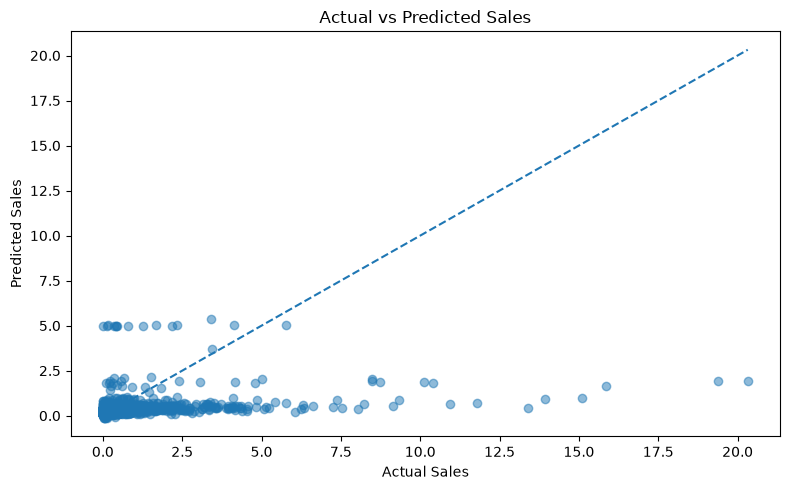

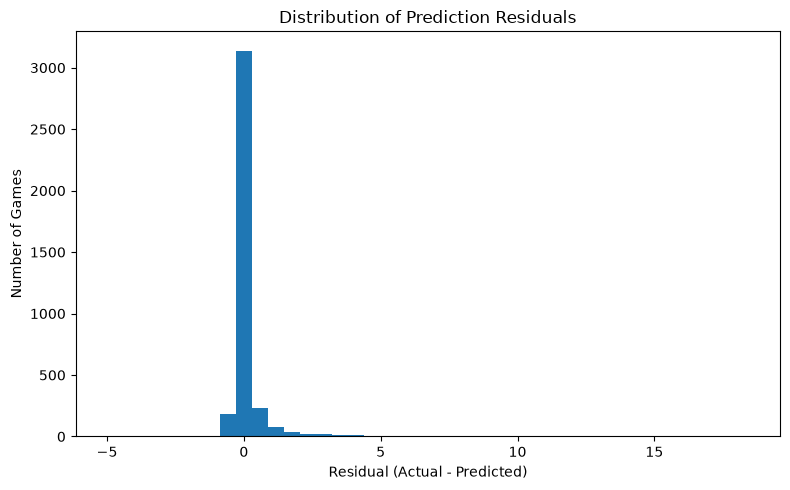

Mean absolute error: 0.3191598899857346
Median absolute error: 0.11445369430837599


In [68]:
error_analysis = pd.DataFrame({
    "Actual Sales": y_test_raw.to_numpy(),
    "Predicted Sales": lasso_test_pred,
})
error_analysis["Residual"] = error_analysis["Actual Sales"] - error_analysis["Predicted Sales"]
error_analysis["Absolute Error"] = error_analysis["Residual"].abs()

display(error_analysis.head())

plt.figure(figsize=(8, 5))
sample_errors = error_analysis.sample(min(5000, len(error_analysis)), random_state=42)
plt.scatter(sample_errors["Actual Sales"], sample_errors["Predicted Sales"], alpha=0.5)
max_value = max(error_analysis["Actual Sales"].max(), error_analysis["Predicted Sales"].max())
plt.plot([0, max_value], [0, max_value], linestyle="--")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(error_analysis["Residual"], bins=40)
plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

print("Mean absolute error:", error_analysis["Absolute Error"].mean())
print("Median absolute error:", error_analysis["Absolute Error"].median())

In [77]:
import joblib

publisher_history = train_data.groupby("publisher")["total_sales"].agg(
    previous_games="count",
    previous_sales="sum"
)

developer_history = train_data.groupby("developer")["total_sales"].agg(
    previous_games="count",
    previous_sales="sum"
)

model_artifacts = {
    "model": poly_model,
    "poly": poly,
    "selector": selector,
    "scaler": scaler,
    "genre_encoder": genre_encoder,
    "console_frequency": console_frequency,
    "publisher_history": publisher_history,
    "developer_history": developer_history,
    "critic_median": float(critic_median),
    "selected_features": list(selected_columns),
    "target_transform": "log1p"
}

artifact_path = "video_game_sales_model.joblib"

joblib.dump(model_artifacts, artifact_path)

print("FINAL Polynomial Regression model saved to:")
print(artifact_path)

print("\nSaved artifacts:")
print(list(model_artifacts.keys()))

FINAL Polynomial Regression model saved to:
video_game_sales_model.joblib

Saved artifacts:
['model', 'poly', 'selector', 'scaler', 'genre_encoder', 'console_frequency', 'publisher_history', 'developer_history', 'critic_median', 'selected_features', 'target_transform']


In [73]:
poly
poly_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](135,)","[ 0.08, 0.06, 0. ,...,-0. , 0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.2255
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,135
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(107)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](135,)","[1728.89,1430.94, 617.75,..., 0. , 0. , 0. ]"


In [70]:
fastapi_code = '\nfrom pathlib import Path\nimport joblib\nimport numpy as np\nimport pandas as pd\nfrom fastapi import FastAPI\nfrom pydantic import BaseModel\n\napp = FastAPI(title="Video Game Sales Predictor", version="1.0")\n\nARTIFACT_PATH = Path(__file__).with_name("video_game_sales_model.joblib")\nartifacts = joblib.load(ARTIFACT_PATH)\n\nmodel = artifacts["model"]\nselector = artifacts["selector"]\nscaler = artifacts["scaler"]\ngenre_encoder = artifacts["genre_encoder"]\nconsole_frequency = artifacts["console_frequency"]\npublisher_history = artifacts["publisher_history"]\ndeveloper_history = artifacts["developer_history"]\ncritic_median = artifacts["critic_median"]\n\nclass GameInput(BaseModel):\n    title: str\n    console: str\n    genre: str\n    publisher: str\n    developer: str\n    critic_score: float | None = None\n\ndef build_features(game: GameInput):\n    title = game.title or ""\n    publisher = game.publisher or "Unknown"\n    developer = game.developer or "Unknown"\n    console = game.console or "Unknown"\n    genre = game.genre or "Unknown"\n\n    publisher_games = publisher_history["previous_games"].get(publisher, 0)\n    publisher_sales = publisher_history["previous_sales"].get(publisher, 0)\n    developer_games = developer_history["previous_games"].get(developer, 0)\n    developer_sales = developer_history["previous_sales"].get(developer, 0)\n\n    row = pd.DataFrame([{\n        "critic_score": critic_median if game.critic_score is None else game.critic_score,\n        "publisher_avg_sales": publisher_sales / publisher_games if publisher_games else 0,\n        "publisher_previous_games": publisher_games,\n        "developer_avg_sales": developer_sales / developer_games if developer_games else 0,\n        "developer_previous_games": developer_games,\n        "title_length": len(title),\n        "title_word_count": len(title.split()),\n        "console_frequency": console_frequency.get(console, 0)\n    }])\n\n    genre_encoded = genre_encoder.transform(pd.DataFrame({"genre": [genre]}))\n    genre_df = pd.DataFrame(\n        genre_encoded,\n        columns=genre_encoder.get_feature_names_out(["genre"])\n    )\n\n    features = pd.concat([row, genre_df], axis=1)\n    features = features.reindex(columns=selector.feature_names_in_, fill_value=0)\n\n    selected = selector.transform(features)\n    scaled = scaler.transform(selected)\n    return scaled\n\n@app.get("/health")\ndef health():\n    return {"status": "ok"}\n\n@app.post("/predict")\ndef predict(game: GameInput):\n    X = build_features(game)\n    log_prediction = model.predict(X)[0]\n    sales_prediction = float(np.expm1(log_prediction))\n    return {"predicted_total_sales": round(max(sales_prediction, 0.0), 4)}\n'
app_path = Path('app.py')
app_path.write_text(fastapi_code.strip() + '\n', encoding='utf-8')
print('FastAPI application written to:', app_path.resolve())

FastAPI application written to: F:\Entri\Video Games Sales Predictor\notebooks\app.py


In [71]:
dockerfile = 'FROM python:3.11-slim\n\nWORKDIR /app\n\nCOPY app.py .\nCOPY video_game_sales_model.joblib .\n\nRUN pip install --no-cache-dir fastapi uvicorn pandas numpy scikit-learn joblib pydantic\n\nEXPOSE 8000\n\nCMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]\n'
docker_path = Path('Dockerfile')
docker_path.write_text(dockerfile, encoding='utf-8')
print('Dockerfile written to:', docker_path.resolve())

Dockerfile written to: F:\Entri\Video Games Sales Predictor\notebooks\Dockerfile
